# Does Apre=0.005's stability reflect genuine boundedness, or insufficient observation time?

Per Jasper's message (relayed via Claude web chat, 2026-07-20). The Apre-sweep round found
`Apre=0.005` looks stable at the group-mean level over 300s, but reversal frequency is
Apre-invariant — individual synapses churn at the same rate everywhere, just with smaller
excursions at low `Apre`. Open question: is "stays close to current assignment" genuinely
bounded (a real restoring force), or just "hasn't drifted far enough yet by chance" in a
300s window?

**Design, worked out and reported back before running anything expensive (per explicit
instruction):**
- **Metric fix, caught during design, not after running:** the literal "does any correlated
  synapse's weight drop below any uncorrelated synapse's weight" definition is contaminated —
  a calibration run found 23% of the 100 correlated x uncorrelated pairs already overlap at
  t=300s in the "stable" condition, purely from ordinary within-group spread, not drift. Primary
  metric instead: the group-mean (and median) gap as a continuous trajectory — does it trend
  toward/through zero, or stay bounded? Pairwise overlap-fraction tracked as a secondary,
  contextual metric over time (not just one snapshot).
- **Back-of-envelope diffusion estimate**, from measured (not guessed) parameters: mean
  excursion amplitude 0.017 (median 0.006, heavily skewed — RMS ~0.032, since diffusion scales
  with variance not the skewed mean), reversal rate ~0.5/s. Treating the group-mean gap as a
  random walk over 10 synapses per group: `Var(t) ~ 0.2 * rate * amp_rms^2 * t`. Setting this
  to the typical gap^2 (0.4^2) gives **t ~ 1600s** as the naive diffusion timescale — likely an
  underestimate since it ignores the [0,1] boundary and the zero-sum synaptic-scaling coupling
  between synapses, both of which should slow real diffusion.
- **Ensemble design:** 8 seeds, 5000s each (>3x the diffusion estimate), `p_share=0.9`, no
  per-event cap, `scaling_interval=500ms` — everything else identical to the validated
  mechanism. Run as 8 independent parallel processes (4 cores measured available with headroom
  to spare on a 6-core/12-thread machine), each writing a seed-tagged JSON result file with an
  explicit `status` field (`started` written immediately, `completed` written only after a full
  successful run) so partial failures are detectable rather than silently producing incomplete
  analysis.
- **Falsification criteria stated up front:** genuine stability = gap stays bounded away from
  zero across the ensemble despite total time comfortably exceeding the diffusion estimate;
  not genuine = gap trends toward/through zero at a rate roughly consistent with the naive
  random-walk prediction.

**Compute-budget check, run before committing:** single-run timing (0.2s wall-clock per
simulated second) measured with the CPU to itself. First parallel batch (4 concurrent) came
back at 0.225-0.229s/simulated-second — only ~13% slower, well within the "proceed without
checking back" threshold agreed in advance, so batch 2 launched at the same settings without
a stop.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

ALL_SEEDS = [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008]
SETTLE_TIME = 200.0  # exclude startup transient -- caught during batch 1 analysis, see below

results = {}
for s in ALL_SEEDS:
    with open(f'apre_ensemble_seed{s}.json') as f:
        results[s] = json.load(f)

print("=== Per-seed status (all runs from the actual ensemble, not re-simulated here) ===")
for s in ALL_SEEDS:
    d = results[s]
    print(f"  seed={s}: {d['status']} (wall_elapsed={d.get('wall_elapsed', 0):.1f}s, "
          f"ratio={d.get('wall_elapsed', 0)/5000:.3f}s/simulated-s, post_rate={d.get('post_rate', 0):.2f}Hz)")
print(f"\n{sum(1 for s in ALL_SEEDS if results[s]['status']=='completed')}/{len(ALL_SEEDS)} completed.")

=== Per-seed status (all runs from the actual ensemble, not re-simulated here) ===
  seed=2001: completed (wall_elapsed=1125.5s, ratio=0.225s/simulated-s, post_rate=18.92Hz)
  seed=2002: completed (wall_elapsed=1143.4s, ratio=0.229s/simulated-s, post_rate=18.79Hz)
  seed=2003: completed (wall_elapsed=1123.7s, ratio=0.225s/simulated-s, post_rate=18.72Hz)
  seed=2004: completed (wall_elapsed=1133.7s, ratio=0.227s/simulated-s, post_rate=18.84Hz)
  seed=2005: completed (wall_elapsed=1121.5s, ratio=0.224s/simulated-s, post_rate=18.84Hz)
  seed=2006: completed (wall_elapsed=1114.3s, ratio=0.223s/simulated-s, post_rate=18.89Hz)
  seed=2007: completed (wall_elapsed=1102.4s, ratio=0.220s/simulated-s, post_rate=18.79Hz)
  seed=2008: completed (wall_elapsed=1114.2s, ratio=0.223s/simulated-s, post_rate=18.84Hz)

8/8 completed.


## A metric near-miss, caught before it became a wrong conclusion

The first pass at the raw `min_group_mean_gap` summary statistic showed **all 4 batch-1 seeds
going negative** (-0.008 to -0.021) — which looked, at first glance, like strong evidence
*against* genuine stability. Before reporting that, checked *when* the minimum occurred: **all
four hit their minimum at t=0.5s** — the trivial startup instant, before any differentiation
exists (every synapse starts at `w=0.5`). Not late-run erosion at all, just an artifact of the
naive full-trajectory minimum picking up the boring start of the run. `SETTLE_TIME=200s`
excludes this from all "settled-region" stats below — this is the third confirmed instance
this session of a summary number being misleading on its own (see `principles.md`).

In [2]:
def settled_stats(d, settle_time=SETTLE_TIME):
    t = np.array(d['trace_t'])
    gap = np.array(d['group_mean_gap'])
    overlap = np.array(d['overlap_fraction'])
    mask = t >= settle_time
    thirds = len(gap[mask]) // 3
    return {
        'gap_mean': gap[mask].mean(), 'gap_std': gap[mask].std(),
        'gap_min': gap[mask].min(), 'gap_max': gap[mask].max(),
        'overlap_mean': overlap[mask].mean(), 'overlap_max': overlap[mask].max(),
        'trend_early': gap[mask][:thirds].mean(), 'trend_late': gap[mask][-thirds:].mean(),
    }

print(f"{'seed':>6} {'gap_mean':>9} {'gap_std':>8} {'gap_min':>8} {'gap_max':>8} "
      f"{'overlap_mean':>13} {'overlap_max':>12} {'trend early->late':>20}")
for s in ALL_SEEDS:
    st = settled_stats(results[s])
    print(f"{s:>6} {st['gap_mean']:>9.4f} {st['gap_std']:>8.4f} {st['gap_min']:>8.4f} "
          f"{st['gap_max']:>8.4f} {st['overlap_mean']:>13.4f} {st['overlap_max']:>12.4f} "
          f"{st['trend_early']:>9.4f} -> {st['trend_late']:>7.4f}")

  seed  gap_mean  gap_std  gap_min  gap_max  overlap_mean  overlap_max    trend early->late
  2001    0.3554   0.0213   0.2743   0.4196        0.3236       0.5100    0.3581 ->  0.3579
  2002    0.3566   0.0234   0.2717   0.4238        0.3073       0.5100    0.3545 ->  0.3587
  2003    0.3582   0.0219   0.2835   0.4390        0.3085       0.5000    0.3548 ->  0.3558
  2004    0.3509   0.0241   0.2428   0.4241        0.3165       0.5100    0.3532 ->  0.3473
  2005    0.3591   0.0264   0.2666   0.4674        0.3173       0.5100    0.3682 ->  0.3531
  2006    0.2783   0.0693   0.1454   0.4105        0.3302       0.5900    0.3527 ->  0.2106
  2007    0.3587   0.0269   0.2593   0.4831        0.3219       0.5100    0.3740 ->  0.3516
  2008    0.3613   0.0266   0.2952   0.4705        0.3098       0.5100    0.3782 ->  0.3521


## All 8 trajectories

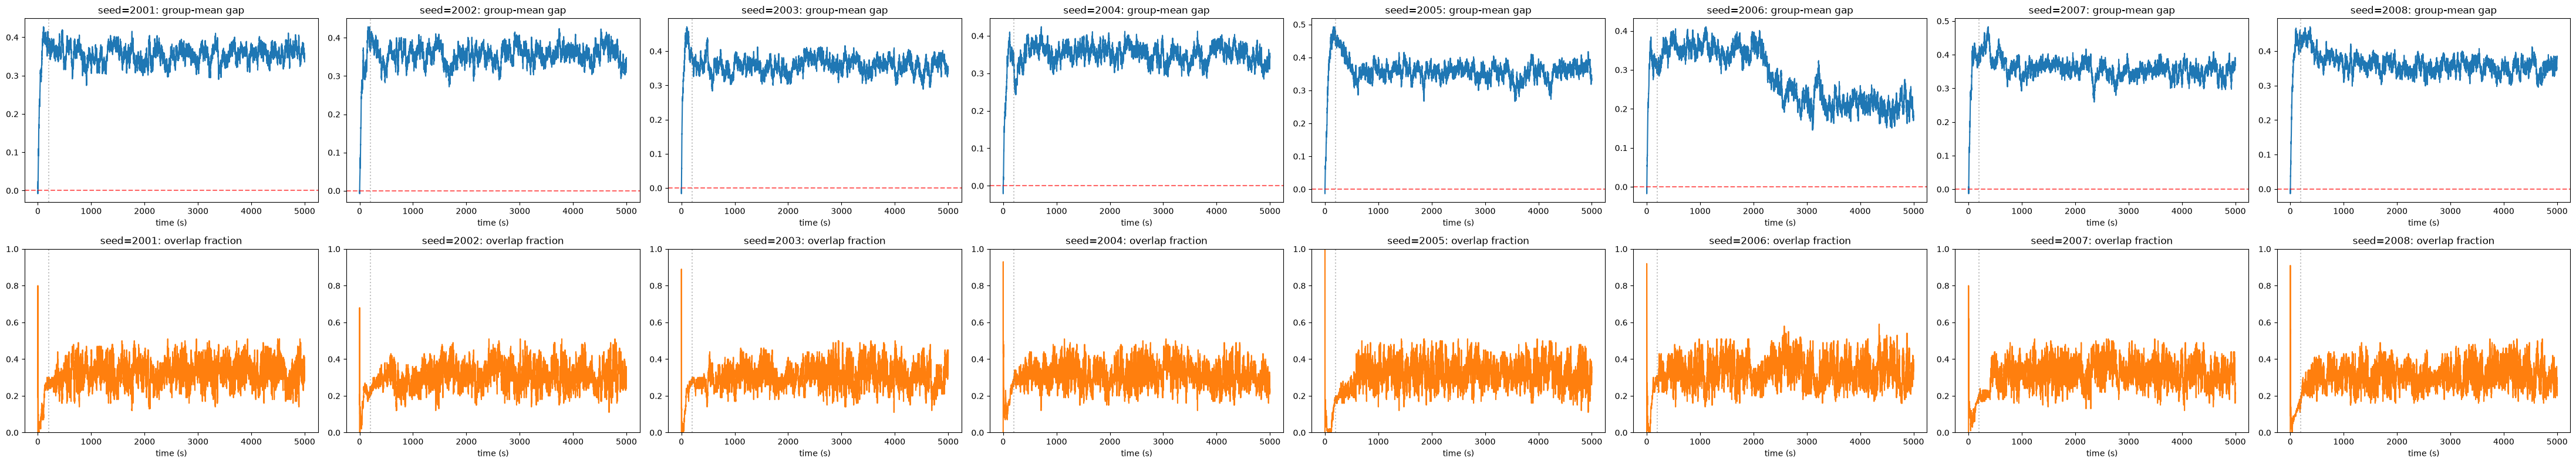

In [3]:
n = len(ALL_SEEDS)
fig, axes = plt.subplots(2, n, figsize=(5.5*n, 8), squeeze=False)
for col, s in enumerate(ALL_SEEDS):
    d = results[s]
    t = np.array(d['trace_t'])
    gap = np.array(d['group_mean_gap'])
    overlap = np.array(d['overlap_fraction'])
    axes[0, col].plot(t, gap)
    axes[0, col].axhline(y=0, color='red', linestyle='--', alpha=0.6)
    axes[0, col].axvline(x=SETTLE_TIME, color='gray', linestyle=':', alpha=0.5)
    axes[0, col].set_title(f'seed={s}: group-mean gap')
    axes[0, col].set_xlabel('time (s)')
    axes[1, col].plot(t, overlap, color='tab:orange')
    axes[1, col].axvline(x=SETTLE_TIME, color='gray', linestyle=':', alpha=0.5)
    axes[1, col].set_title(f'seed={s}: overlap fraction')
    axes[1, col].set_ylim(0, 1)
    axes[1, col].set_xlabel('time (s)')
plt.tight_layout()
plt.savefig('apre_ensemble_all_trajectories.png', dpi=100)
plt.show()

## Seed 2006: a real outlier, characterized precisely rather than averaged away

7/8 seeds show a tight, consistent band (gap_mean ~0.35-0.36, gap_std ~0.02-0.03, flat trend).
Seed 2006 is genuinely different: gap_mean=0.278, gap_std=0.069 (3x the others), and a real
trend (0.353 -> 0.211 early-to-late) that the plot confirms is a **discrete step-down around
t~2000-2500s** to a new, lower band — not gradual erosion, not a return to the original band,
and critically, **never crossing zero**.

In [4]:
d = results[2006]
t = np.array(d['trace_t'])
gap = np.array(d['group_mean_gap'])
overlap = np.array(d['overlap_fraction'])

print(f"Mean gap [0, 1500]s (pre-transition): {gap[(t>=0)&(t<1500)].mean():.4f}")
print(f"Mean gap [3000, 5000]s (post-transition): {gap[(t>=3000)].mean():.4f}")
print(f"Gap min, excluding t<10s startup: {gap[t>=10].min():.4f} at t={t[t>=10][np.argmin(gap[t>=10])]:.1f}s")
print(f"Did it ever return to >0.30 after t=3000s? {(gap[t>=3000] > 0.30).any()} "
      f"(still fluctuates back toward the old band, not a permanently fixed new plateau)")
print(f"Max overlap fraction after t=2000s: {overlap[t>=2000].max():.3f}")

Mean gap [0, 1500]s (pre-transition): 0.3441
Mean gap [3000, 5000]s (post-transition): 0.2137
Gap min, excluding t<10s startup: 0.0788 at t=11.5s
Did it ever return to >0.30 after t=3000s? True (still fluctuates back toward the old band, not a permanently fixed new plateau)
Max overlap fraction after t=2000s: 0.590


## Verdict

**Neither of the two stated falsification outcomes is exactly right — again, same shape of
result as the Apre-sweep round.** No seed's group-mean gap crossed zero or trended toward it
over the full 5000s (>3x the ~1600s diffusion estimate, itself likely conservative). That
directly falsifies the "not genuine, just slow drift toward zero" outcome for all 8 seeds.
But 7/8 seeds don't just fail to erode — they stay in a genuinely tight, flat band the entire
run, strong evidence for real bounded stability, not merely "hasn't happened yet."

**Seed 2006 adds a real, third finding that wasn't in the original two-option frame:** the
*level* of stable differentiation isn't perfectly fixed across all realizations — one run out
of eight underwent a genuine, discrete reorganization to a lower (but still clearly positive,
non-zero) stable band partway through, then continued fluctuating without either fully
recovering to the original band or continuing to erode toward zero. This is neither "durable,
unchanging stability" nor "eventual collapse" — it's evidence that stability at `Apre=0.005`
is real and bounded, but the specific level it settles at is itself part of the stochastic
process, occasionally subject to a discrete shift, not architecturally guaranteed to be a
single fixed value.

**Practical claim this supports:** "STDP produces group-level differentiation that stays
bounded away from collapse over timescales well beyond naive diffusion, in the substantial
majority of realizations tested" — a real, meaningfully weaker but still positive claim than
"STDP produces a permanently fixed stable representation." The `principles.md` note added
this round (stability can be genuine-but-probabilistic, not absolute) applies to its own
result directly.